In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [74]:
amzn = pd.read_csv('AMZN.csv')

In [75]:
amzn.isna().sum().sum()


np.int64(0)

In [76]:
amzn['Date'] = pd.to_datetime(amzn['Date'])

In [77]:
amzn.set_index('Date', inplace=True)

In [78]:
amzn['diff'] = amzn['Close'] - amzn['Open']

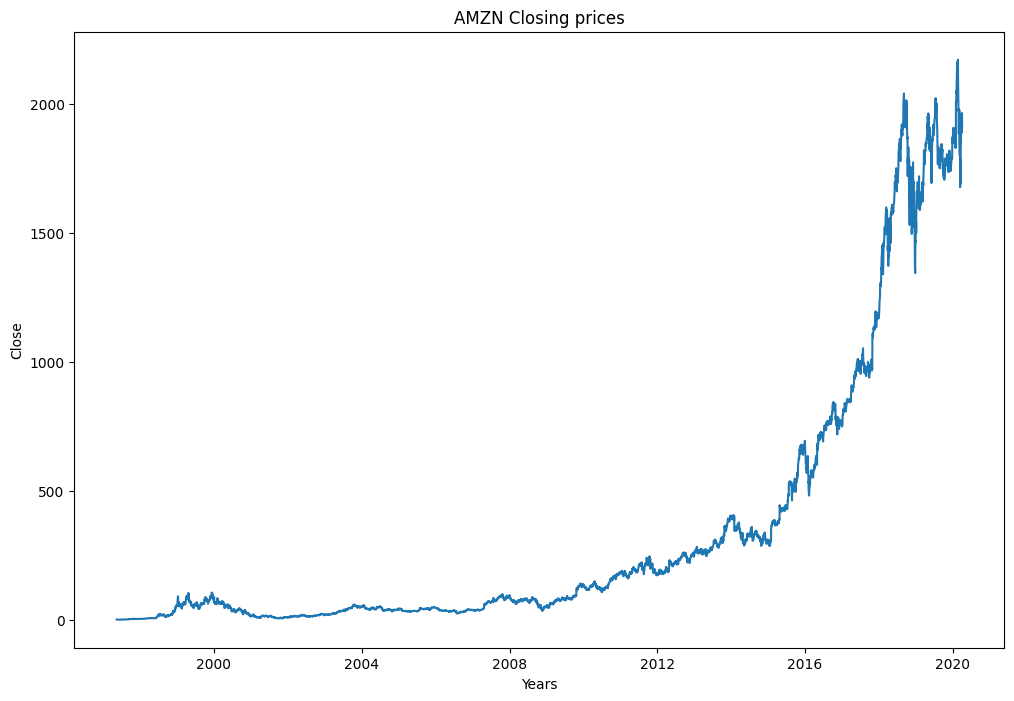

In [79]:
plt.figure(figsize=(12,8))
plt.plot(amzn['Close'])
plt.xlabel('Years')
plt.ylabel('Close')
plt.title('AMZN Closing prices')
plt.show()

In [80]:
amzn = amzn.loc[pd.Timestamp('2015-01-01'):pd.Timestamp('2019-12-31')]

In [81]:
amzn.head()

,Open,High,Low,Close,Adj Close,Volume,diff
Date,,,,,,,
2015-01-02,312.579987,314.750000,306.959991,308.519989,308.519989,2783200,-4.059998
2015-01-05,307.010010,308.380005,300.850006,302.190002,302.190002,2774200,-4.820007
2015-01-06,302.239990,303.000000,292.380005,295.290009,295.290009,3519000,-6.949982
2015-01-07,297.500000,301.279999,295.329987,298.420013,298.420013,2640300,0.920013
2015-01-08,300.320007,303.140015,296.109985,300.459991,300.459991,3088400,0.139984


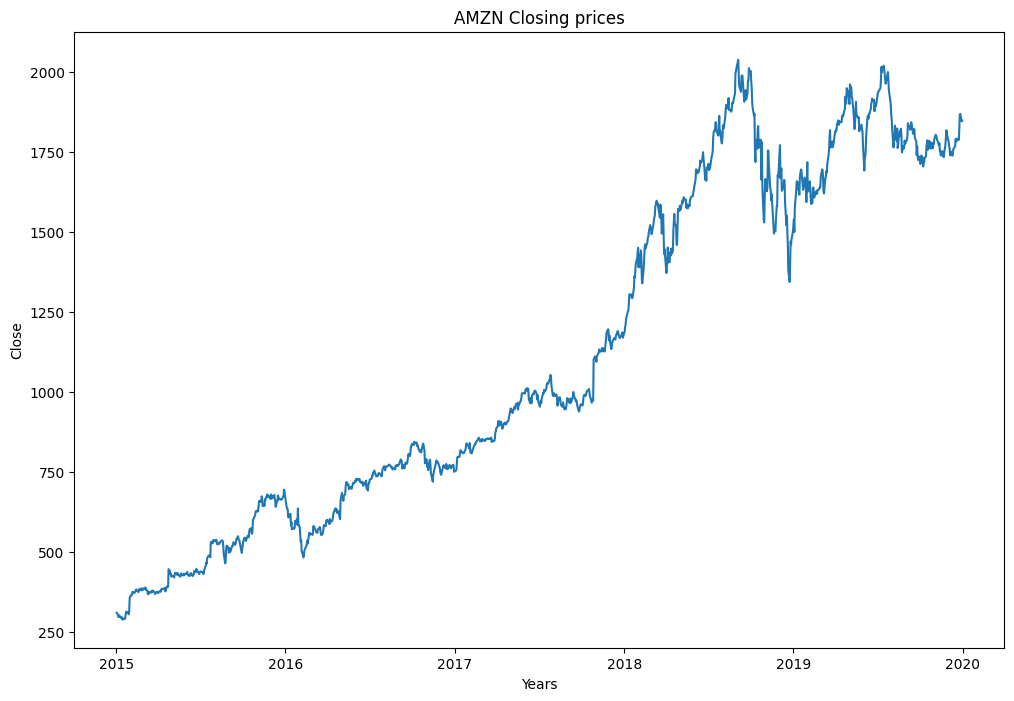

In [82]:
# only using the data from the time that it started to become really high
plt.figure(figsize=(12,8))
plt.plot(amzn['Close'])
plt.xlabel('Years')
plt.ylabel('Close')
plt.title('AMZN Closing prices')
plt.show()

In [83]:
# pct = (today's price - yesterday's price) / yesterday's price
daily_close = amzn[['Adj Close']]
pct = daily_close.pct_change()
pct.fillna(0, inplace=True)
pct.head()

,Adj Close
Date,
2015-01-02,0.000000
2015-01-05,-0.020517
2015-01-06,-0.022833
2015-01-07,0.010600
2015-01-08,0.006836


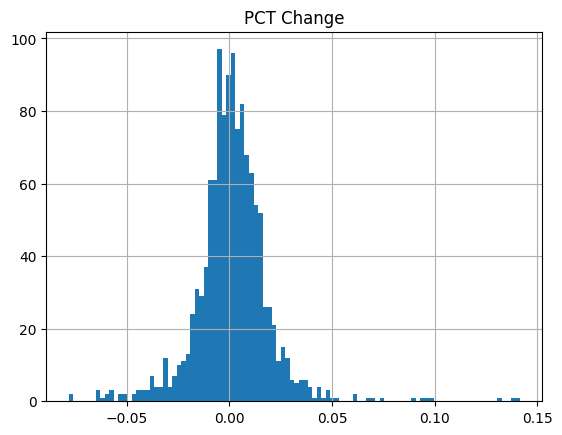

         Adj Close
count  1258.000000
mean      0.001591
std       0.018419
min      -0.078197
25%      -0.006546
50%       0.001303
75%       0.009932
max       0.141311


In [84]:
pct.hist(bins=100)
plt.title('PCT Change')
plt.show()
print(pct.describe())

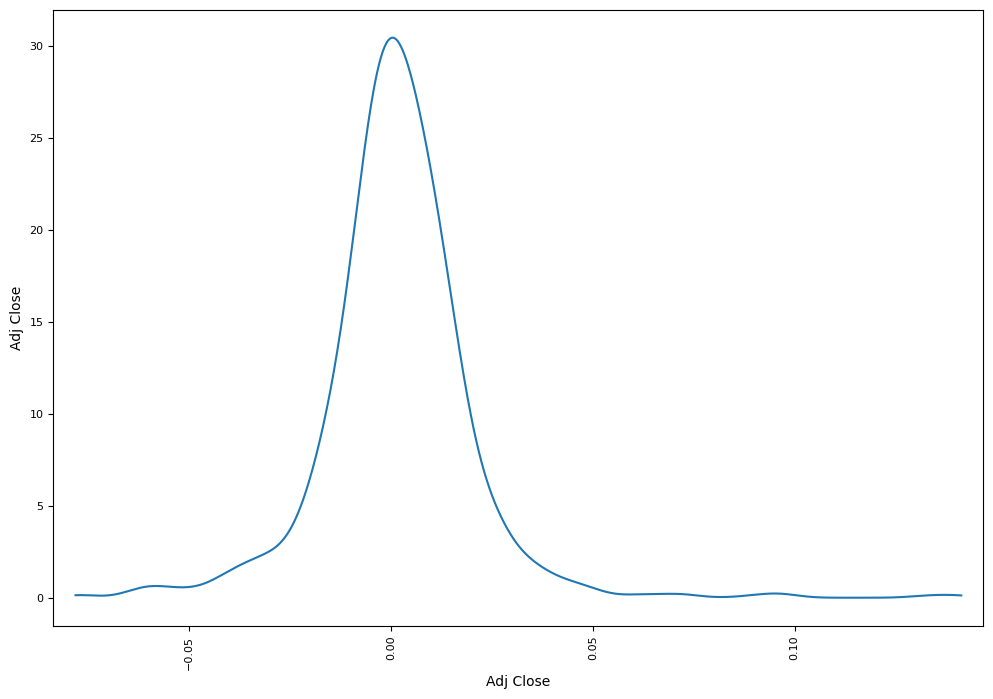

In [85]:
#vol percentage change
pd.plotting.scatter_matrix(pct,diagonal='kde' ,figsize=(12,8))
plt.show()

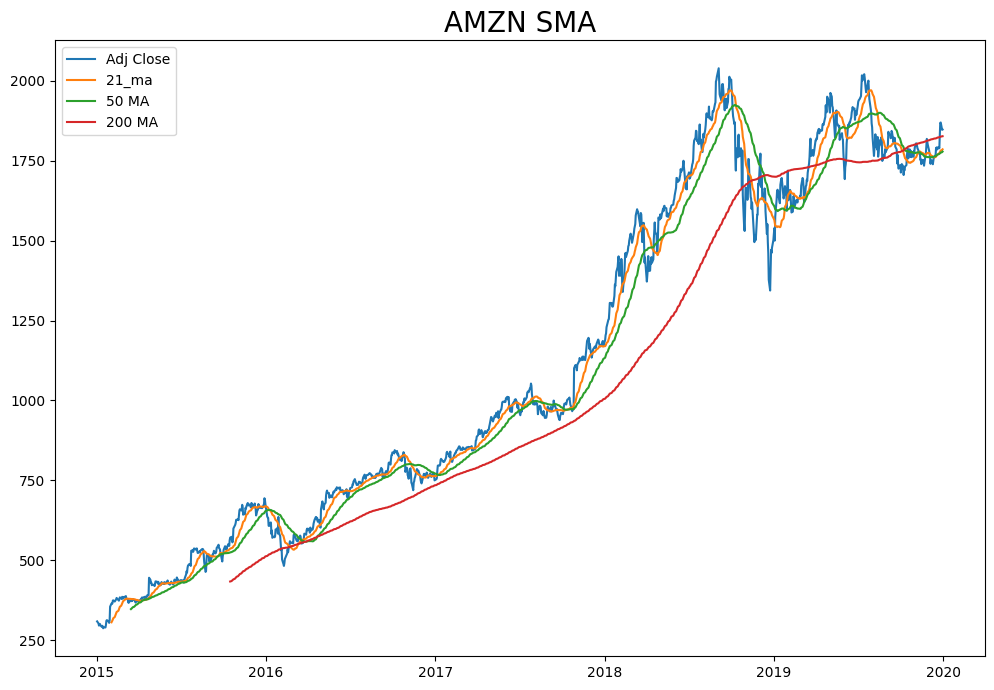

In [86]:
# use moving averages to smooth out the price
#EMA gives more weight to recent prices
# SMA for 1 trading month, a quarter, and a year
amzn = amzn.copy()
adj_close = amzn['Adj Close']
amzn['21_ma'] = adj_close.rolling(window=21).mean()
amzn['50_ma'] = adj_close.rolling(window=50).mean()
amzn['200_ma'] = adj_close.rolling(window=200).mean()

plt.figure(figsize=(12,8))
plt.plot(amzn['Adj Close'], label='Adj Close')
plt.plot(amzn['21_ma'], label='21_ma')
plt.plot(amzn['50_ma'], label='50 MA')
plt.plot(amzn['200_ma'], label='200 MA')
plt.title('AMZN SMA', fontsize=20)
plt.legend()
plt.show()



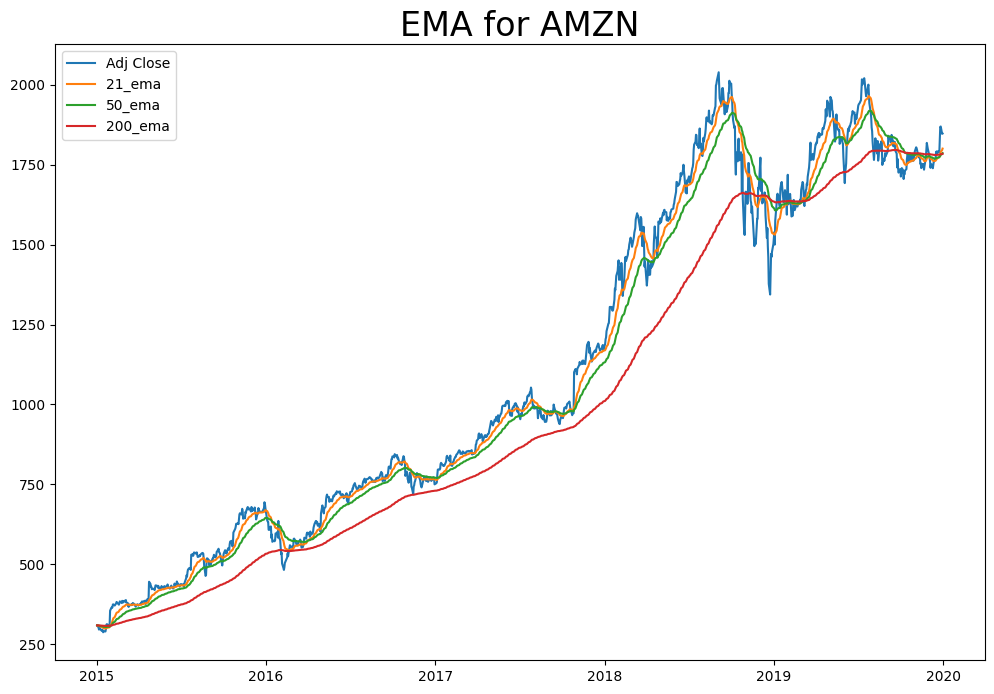

In [87]:
amzn = amzn.copy()
adj_close = amzn['Adj Close']

plt.figure(figsize=(12,8))
plt.plot(amzn['Adj Close'], label='Adj Close')
plt.plot(adj_close.ewm(span=21 ,adjust=False).mean(),   label='21_ema')
plt.plot(adj_close.ewm(span=50 ,adjust=False).mean(),   label='50_ema')
plt.plot(adj_close.ewm(span=200 ,adjust=False).mean(),   label='200_ema')
plt.title('EMA for AMZN', fontsize=24)
plt.legend()
plt.show()

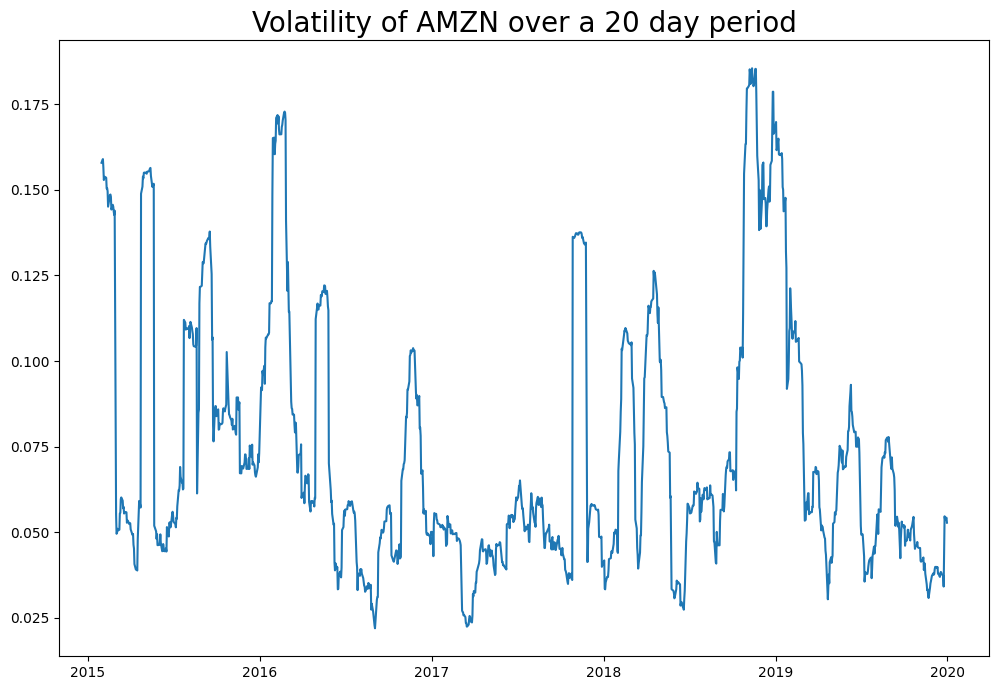

In [88]:
# Volatility Calc
min_period = 20
vol = pct.rolling(min_period).std() * np.sqrt(min_period)
plt.figure(figsize=(12,8))
plt.plot(vol)
plt.title('Volatility of AMZN over a 20 day period', fontsize=20)
plt.show()

In [89]:
# Moving Averages CrossOver that follows fibonacci so 13/49 for 94-days of 4.9% gain

short_w = 13
long_w = 49

signals = pd.DataFrame(index=amzn.index)
signals['signal'] = 0.0

signals['short_w'] = amzn['Close'].rolling(window=short_w, min_periods=1, center=False).mean()

signals['long_w'] = amzn['Close'].rolling(window=long_w, min_periods=1, center=False).mean()

signals.loc[signals.index[short_w:], 'signal'] = np.where(signals['short_w'][short_w:] > signals['long_w'][short_w:], 1.0, 0.0)

signals['positions'] = signals['signal'].diff()
signals


,signal,short_w,long_w,positions
Date,,,,
2015-01-02,0.0,308.519989,308.519989,NaN
2015-01-05,0.0,305.354996,305.354996,0.0
2015-01-06,0.0,302.000000,302.000000,0.0
2015-01-07,0.0,301.105003,301.105003,0.0
2015-01-08,0.0,300.976001,300.976001,0.0
...,...,...,...,...
2019-12-24,0.0,1770.399987,1772.006931,0.0
2019-12-26,1.0,1779.413067,1773.871012,1.0
2019-12-27,1.0,1788.666147,1775.551013,0.0


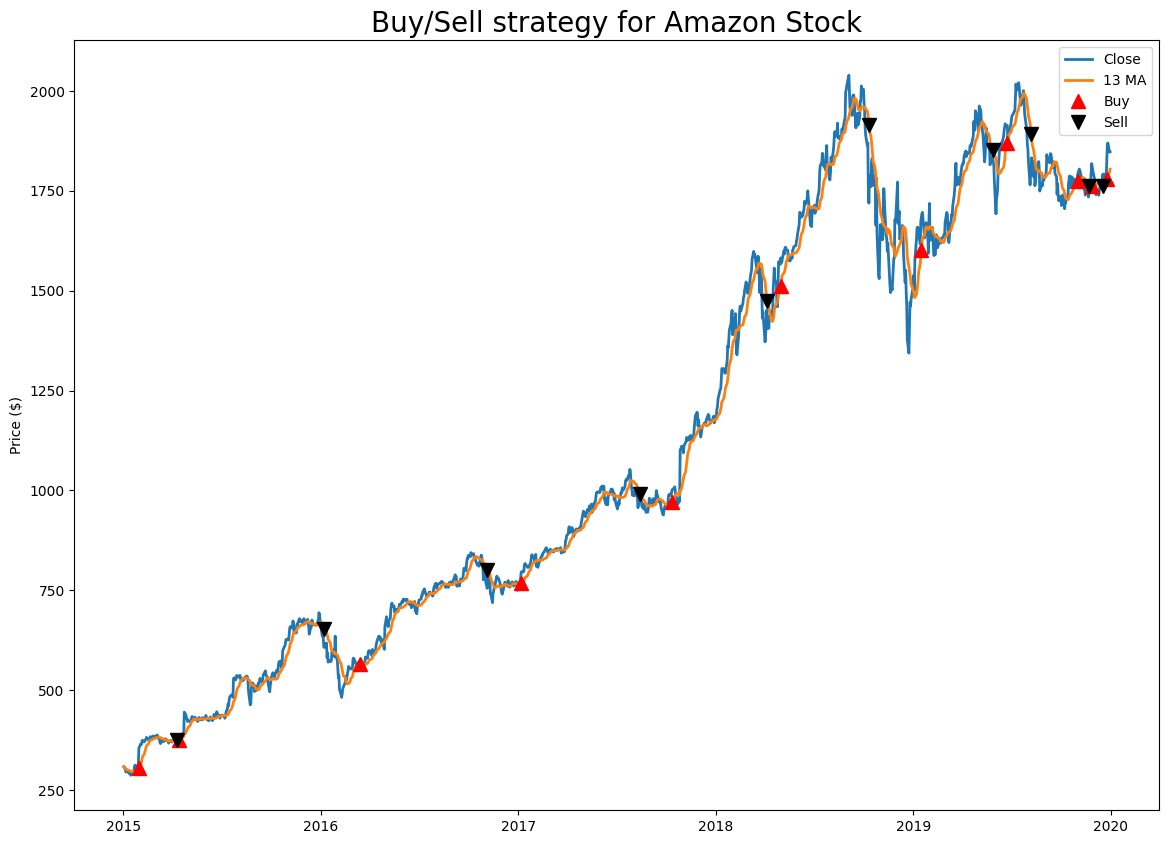

In [90]:
fig = plt.figure(figsize=(14,10))
ax1 = fig.add_subplot(111,  ylabel='Price ($)')
ax1.plot(amzn.index, amzn['Close'], lw=2., label='Close')
ax1.plot(signals.index, signals['short_w'], lw=2.,
  label='13 MA')
ax1.plot(signals.loc[signals.positions == 1.0].index,
         signals.short_w[signals.positions == 1.0],
         '^', markersize=10, color='red', label='Buy')
ax1.plot(signals.loc[signals.positions == -1.0].index,
         signals.short_w[signals.positions == -1.0],
         'v', markersize=10, color='black', label='Sell')
plt.legend(loc='best')
plt.title('Buy/Sell strategy for Amazon Stock', fontsize=20)
plt.show()